# GO-VMP: Global Optimization for View Motion Planning in Fruit Mapping — minimal ILP demonstration

**Paper:** A. I. Jose, S. Pan, T. Zaenker, R. Menon, S. Houben, M. Bennewitz,
*GO-VMP: Global Optimization for View Motion Planning in Fruit Mapping*, arXiv:2503.03912v2,
https://arxiv.org/abs/2503.03912 — **Author code:** https://github.com/AllenIsaacJose/GO-VMP
(pinned commit `ba17f5f5f2c674a7a84b047cb25dea00376fed64`, AGPL-3.0).

**What this notebook does (executed scope):** it rebuilds the paper's core contribution — the joint
**S**hortest-**H**amiltonian-**P**ath (as a TSP with a virtual end vertex) + **S**et-**C**overing
**P**roblem ILP with lazy subtour elimination (`ViewsVoxelsMotion` in
`src/view_motion_planner/src/views_voxels_motion.cpp`) — with **gurobipy** and solves it on a small
deterministic synthetic crop-row segment: fruit ROI voxels, occluding leaf voxels, sampled view poses,
a 5-nearest-neighbor sparse view-motion graph, and motion costs.

**ADAPTED PYTHON DEMONSTRATION — AI-assisted translation from ROS/C++; the authors did not provide
this Colab implementation.** The authors' planner is a ROS Noetic + Gazebo + MoveIt + OctoMap + Gurobi
C++ pipeline that cannot run on Colab. The executed example and listed checks were validated, but
untested behavior is not guaranteed. The optimization model is a faithful structural port; the scene,
visibility and motion-cost inputs are geometric proxies (each deviation is labeled at its cell).

**このノートブックについて:** 論文 GO-VMP の中核である「経路問題(SHPP)+被覆問題(SCP)の統合 ILP(部分巡回除去を
遅延制約で実装)」を gurobipy で再現し、小さな合成作物列セグメントに対して解きます。ROS/Gazebo/MoveIt/
OctoMap 依存は Colab では実行できないため、可視性判定と移動コストは幾何学的代理実装です(各セルに明記)。

**Execution status:** CPU-only notebook (no GPU needed — small MILP + geometry). Validated end-to-end
on a fresh Google Colab CPU runtime; see the final results cells for the actual outputs of that run.

**Limitations:** single-shot optimization of one mini segment (the paper plans per segment on a 12 s
re-planning cycle inside Gazebo); 5 cm voxel proxy vs the paper's 1 cm OctoMap; Euclidean pose-space
distance instead of MoveIt joint-space distance; gurobipy's pip size-limited license (≤2000 vars /
constraints) is sufficient here but would not scale to the paper's full instances. This is *not* a
reproduction of the paper's dataset-level results (Tables I–IV).

## Runtime selection / 実行環境

Select **Runtime → Change runtime type → CPU** (the default). No GPU is used or required: the workload
is a small mixed-integer program and simple geometry. `Runtime → Run all` takes a few minutes end to
end, dominated by `pip install gurobipy` and the license check; downloads are limited to one small
source file from GitHub used for provenance.

**ランタイムは CPU で十分です(GPU 不要)。** [ランタイム]→[すべてのセルを実行] で数分で完了します。

### Setup — install the Gurobi Python solver

`gurobipy` from PyPI ships a **size-limited license** (models up to 2000 variables and 2000 linear
constraints) that is enough for this demonstration instance; no license key or account is needed. We
print the installed Gurobi version and verify the license is usable by creating and discarding a tiny
model. If this step fails, later cells cannot run.

**セットアップ:** pip から `gurobipy` を入れます。PyPI 版にはサイズ制限付きライセンス(変数・制約それぞれ
2000 まで)が付属し、ライセンスキー不要です。小さなモデルを作成してライセンスを確認します。

In [ ]:
%pip install -q gurobipy

import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt

print("Gurobi version:", gp.gurobi.version())

# Verify the size-limited license is usable with a tiny throwaway model
_m = gp.Model("license_check")
_m.addVar(vtype=GRB.BINARY)
_m.optimize()
assert _m.Status == GRB.OPTIMAL
print("gurobipy license OK (tiny model solved optimally)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━ 13.1/14.9 MB 121.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 60.9 MB/s eta 0:00:00


Gurobi version: (13, 0, 3)
Restricted license - for non-production use only - expires 2027-11-29


Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")


CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]


...

Thread count was 1 (of 2 available processors)


Solution count 1: 0 


Optimal solution found (tolerance 1.00e-04)


Best objective 0.000000000000e+00, best bound 0.000000000000e+00, gap 0.0000%


gurobipy license OK (tiny model solved optimally)


### Provenance — pin and verify the author's ILP source

We download the single author file that defines the optimization model,
`src/view_motion_planner/src/views_voxels_motion.cpp`, from the pinned commit via the public
`raw.githubusercontent.com` URL, and verify its **git blob SHA-1** (`fd55ba1c…`) and size (13,592
bytes) against the repository tree API of commit `ba17f5f5f2c674a7a84b047cb25dea00376fed64`. The key
ILP lines are printed so the port in later cells can be checked against the original. This is author
source code (AGPL-3.0) — citation required if reused.

**出典の確認:** 著者リポジトリの固定コミットから ILP 定義ファイルを 1 つだけ取得し、git blob SHA-1 と
サイズを検証します。これは AGPL-3.0 の著者コードです。

In [ ]:
import urllib.request, hashlib, json

COMMIT = "ba17f5f5f2c674a7a84b047cb25dea00376fed64"
RELPATH = "src/view_motion_planner/src/views_voxels_motion.cpp"
EXPECTED_BLOB_SHA = "fd55ba1cc289da1e6c7b5a623b35785e6394bac9"
EXPECTED_SIZE = 13592

url = f"https://raw.githubusercontent.com/AllenIsaacJose/GO-VMP/{COMMIT}/{RELPATH}"
req = urllib.request.Request(url, headers={"User-Agent": "colab-govmp-demo/1.0"})
with urllib.request.urlopen(req, timeout=60) as r:
    src = r.read()
blob_sha = hashlib.sha1(b"blob %d\0" % len(src) + src).hexdigest()
assert len(src) == EXPECTED_SIZE, f"unexpected size {len(src)}"
assert blob_sha == EXPECTED_BLOB_SHA, f"unexpected blob sha {blob_sha}"
print(f"verified {RELPATH} @ {COMMIT}")
print(f"  bytes={len(src)}  git blob sha1={blob_sha}")

lines = src.decode().splitlines()
# Show the coverage-constraint definition from the author's file (lines 242-252)
print("\n--- author's fullCoverageConstraints (views_voxels_motion.cpp:242-252) ---")
print("\n".join(lines[241:252]))

verified src/view_motion_planner/src/views_voxels_motion.cpp @ ba17f5f5f2c674a7a84b047cb25dea00376fed64
  bytes=13592  git blob sha1=fd55ba1cc289da1e6c7b5a623b35785e6394bac9

--- author's fullCoverageConstraints (views_voxels_motion.cpp:242-252) ---
void ViewsVoxelsMotion::fullCoverageConstraints()
{
  // Full coverage constraints
  for (int j = 0; j < num_of_voxel; j++) {
    GRBLinExpr subject_of_voxel;
    for (int i = 0; i < num_of_view; i++)
      if (connection_graph[i][j] == 1) subject_of_voxel += view_selection[i];
    model->addConstr(subject_of_voxel >= 1, "coverage" + std::to_string(j));
  }
  ROS_INFO_STREAM("Full coverage constraints set");
}


### The minimal scene — one synthetic crop-row segment

The paper's Gazebo glasshouse (Scenario 1: 24 plants / 120 fruits in two rows at two height levels)
cannot run on Colab, so we build the smallest scientifically analogous input: a 1.8 m crop-row segment
with 3 plants, **9 capsicum fruit ROI voxels** (red targets, the SCP coverage set) and **leaf/stem
voxels** (occupied occluders, the ray-casting obstacles). The layout is hard-coded and fully
deterministic; voxel size is 5 cm (paper OctoMap: 1 cm). This scene is a demo analogue, **not** a file
from the author's repository.

**最小シーン:** 論文の Gazebo 環境の代わりに、座標を固定した決定論的な合成セグメント(果実 ROI ボクセル
9 個、葉/茎の遮蔽ボクセル)を構築します。ボクセルは 5 cm(論文は 1 cm)で、これはデモ用の類似入力です。

In [ ]:
VOX = 0.05  # voxel edge length [m] (paper OctoMap resolution: 0.01 m)

# 9 fruit ROI centers [m]: 3 plants along x, fruits at two height levels
fruit_pos = np.array([
    [0.30, 0.88, 0.50], [0.33, 0.92, 0.95], [0.27, 0.90, 1.15],
    [0.90, 0.86, 0.45], [0.93, 0.90, 0.90], [0.87, 0.92, 1.10],
    [1.50, 0.88, 0.55], [1.53, 0.92, 0.95], [1.47, 0.90, 1.15],
])

# Leaf occluder clusters (center, radius) placed on specific camera-to-fruit sight lines,
# plus vertical stem columns behind the fruit line — the occupied voxels for ray casting
leaf_clusters = [((0.36, 1.06, 0.60), 0.07),
                 ((0.96, 1.06, 0.56), 0.07),
                 ((0.93, 1.06, 0.94), 0.07)]
STEM_XS = [0.30, 0.90, 1.50]

def vox_key(p):
    return tuple(np.floor(np.asarray(p) / VOX).astype(int))

occupied = set()
for (cx, cy, cz), r in leaf_clusters:
    lo = np.floor((np.array([cx, cy, cz]) - r) / VOX).astype(int)
    hi = np.ceil((np.array([cx, cy, cz]) + r) / VOX).astype(int)
    for i in range(lo[0], hi[0] + 1):
        for j in range(lo[1], hi[1] + 1):
            for k in range(lo[2], hi[2] + 1):
                c = (np.array([i, j, k]) + 0.5) * VOX
                if np.linalg.norm(c - [cx, cy, cz]) <= r:
                    occupied.add((i, j, k))
for x0 in STEM_XS:
    for z in np.arange(0.20, 1.25, VOX):
        occupied.add(vox_key([x0, 0.78, z]))

print(f"fruits: {len(fruit_pos)}, occupied voxels: {len(occupied)} "
      f"(leaf clusters: {len(leaf_clusters)}, stems: {len(STEM_XS)})")

fruits: 9, occupied voxels: 92 (leaf clusters: 3, stems: 3)


### Input preview — the segment, its fruits, occluders and the trolley rail

Before planning, we render the actual demo input in 3D: fruit ROI voxels (the coverage targets), the
occupied leaf/stem voxels the camera rays must not cross, and the band of the rail where the trolley
arm camera can travel (paper Sec. III: RGB-D camera on a UR5 arm mounted on a height-adjustable
trolley). This preview is created for this notebook; it is not an author figure.

**入力プレビュー:** 果実 ROI(被覆対象)、光線遮蔽となる葉/茎ボクセル、トロリー・アームカメラの
可動帯を 3D 散布図で表示します(本ノートブック用に作成した図であり、論文の図ではありません)。

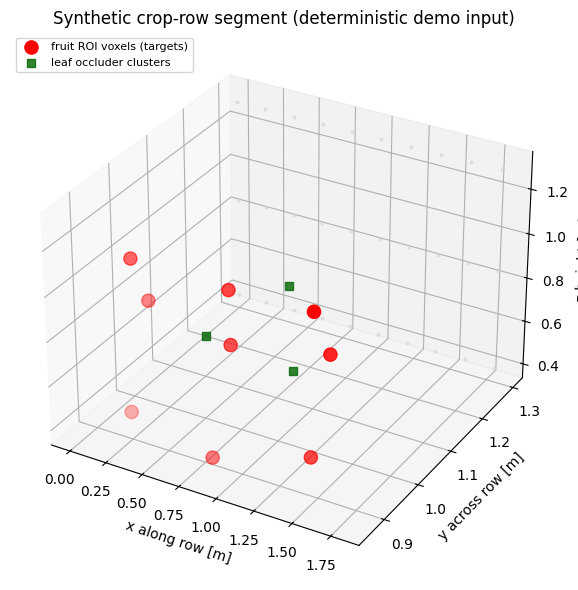

In [ ]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

fp = np.array(fruit_pos)
ax.scatter(fp[:, 0], fp[:, 1], fp[:, 2], c="red", s=90, marker="o", label="fruit ROI voxels (targets)")
leaf_plotted = False
for (cx, cy, cz), r in leaf_clusters:
    ax.scatter([cx], [cy], [cz], c="darkgreen", s=40, marker="s", alpha=0.8,
               label=None if leaf_plotted else "leaf occluder clusters")
    leaf_plotted = True

# trolley camera rail band (workspace proxy for the arm on the trolley)
for xr in np.linspace(0.0, 1.8, 10):
    for zr in np.linspace(0.4, 1.3, 3):
        ax.scatter([xr], [1.30], [zr], c="lightgray", s=4, alpha=0.5)

ax.set_xlabel("x along row [m]"); ax.set_ylabel("y across row [m]"); ax.set_zlabel("z height [m]")
ax.set_title("Synthetic crop-row segment (deterministic demo input)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

### View-pose sampling and visibility (proxy for OctoMap ray casting)

Following the paper's view-sampling stage, candidate camera poses are generated around each fruit ROI
(looking at it) and behind the canopy (looking at unknown-space proxies, the "exploration" views), then
kept inside the trolley-arm workspace band. Visibility between a view and a fruit follows the author's
check in `viewpose_graph.cpp:1172-1206`: (a) the target lies inside the sensor cone (D435 half-FOV
proxy 40°, range 1.0 m), and (b) the straight ray from camera to target crosses **no occupied voxel**
— a geometric proxy for `octomap::computeRayKeys` + `isNodeOccupied`. Result: the connection graph
`conn[view][fruit]` used by the coverage constraints.

**視点生成と可視性:** 果実を向く視点と unknown 探索用の視点をサンプリングし、視野角(半値 40°)と
レイキャスト(占有ボクセル交差)で可視性を判定します。OctoMap の `computeRayKeys` の幾何学的代理実装です。

In [ ]:
CAM_RANGE = 1.0   # sensor range proxy [m]
HALF_FOV = np.deg2rad(40.0)  # D435 half-FOV proxy [rad]

def occluded(p, t, clearance=0.06):
    d = np.asarray(t) - np.asarray(p)
    L = np.linalg.norm(d)
    n = max(int(L / (VOX / 2)), 1)
    for s in np.linspace(0.0, 1.0, n + 1):
        if s * L < clearance or (1 - s) * L < clearance:
            continue
        if vox_key(np.asarray(p) + s * d) in occupied:
            return True
    return False

views, view_fwd, view_kind = [], [], []
# the start pose's orientation is unconstrained in this proxy, so it sees without an FOV cone check
views.append(np.array([0.05, 1.30, 0.80])); view_fwd.append(None); view_kind.append("start")

def add_view(pos, target, kind):
    views.append(np.asarray(pos, float))
    view_fwd.append((np.asarray(target) - pos) / np.linalg.norm(target - pos))
    view_kind.append(kind)

# fruit-looking views: fan of positions around each fruit (deduplicated on a 0.1 m grid)
for f in fruit_pos:
    for ang in np.linspace(-0.8, 0.8, 4):
        for dx in (-0.10, 0.10):
            pos = f + np.array([dx, 0.55 * np.cos(ang), 0.55 * np.sin(ang)])
            if not (0.0 <= pos[0] <= 1.8 and 1.0 <= pos[1] <= 1.45 and 0.30 <= pos[2] <= 1.35):
                continue
            if any(np.linalg.norm(pos - v) < 0.10 for v in views):
                continue
            add_view(pos, f, "fruit")
            break

# exploration views: look at unknown-space proxies behind the canopy (paper: OCC-UNK sampling)
expl_targets = [np.array([0.30, 0.62, 0.75]), np.array([0.90, 0.62, 0.80]), np.array([1.50, 0.62, 0.75])]
expl_ids = []
for et in expl_targets:
    pos = et + np.array([0.0, 0.50, 0.10])
    expl_ids.append(len(views))
    add_view(pos, et, "exploration")

n_views = len(views)
conn = np.zeros((n_views, len(fruit_pos)), dtype=int)
n_blocked = 0
for i in range(n_views):
    for j, f in enumerate(fruit_pos):
        d = np.linalg.norm(views[i] - f)
        if d > CAM_RANGE:
            continue
        if view_fwd[i] is not None:
            ang = np.arccos(np.clip(np.dot(view_fwd[i], (f - views[i]) / d), -1, 1))
            if ang > HALF_FOV:
                continue
        if occluded(views[i], f):
            n_blocked += 1
            continue
        conn[i, j] = 1

per_fruit = conn.sum(axis=0)
assert (per_fruit >= 1).all(), f"uncoverable fruit: {per_fruit}"
print(f"views sampled: {n_views} (start 1 + fruit {n_views-1-len(expl_ids)} + exploration {len(expl_ids)})")
print(f"visibility pairs (view,fruit): {conn.sum()}; min/mean views per fruit: {per_fruit.min()}/{per_fruit.mean():.2f}")
print(f"pairs in range+FOV but ray-occluded: {n_blocked}")

views sampled: 28 (start 1 + fruit 24 + exploration 3)
visibility pairs (view,fruit): 58; min/mean views per fruit: 5/6.44
pairs in range+FOV but ray-occluded: 5


### Sparse view-motion graph and motion-cost matrix

The paper builds a **sparse graph**: each view is connected to its 5 nearest neighbors
(`connectNeighbors`/`nearestK` in `viewpose_graph.cpp:77-158`, "sparse (5 neighbors)" in the paper's
ablation), with edge weights approximating manipulator motion cost. The author's C++ sets costs as
`2 x joint-space distance` (`Vmp_2times_actual_cost`, `viewpose_graph.cpp:816`). **Adaptation:** with
no URDF/MoveIt on Colab we use `2 x` Euclidean distance between camera positions; and unlike the
shipped `motionCostMatrix` (whose `if (config.motion_cost_mat_init = …)` assignment-bug initializes
*every* pair), we forbid non-graph edges — the paper-intended sparse graph. A virtual end vertex is
appended with zero-cost edges, exactly as in the author's matrix (`viewpose_graph.cpp:824-833`).

**疎グラフとコスト行列:** 各視点を近傍 5 点と接続します。MoveIt の関節空間距離の代わりに
ユークリッド距離×2 を使用し、非接続ペアは禁止します(著者コードの代入バグによる全対初期化とは異なり、
論文記載の疎グラフに従います)。仮想終端をコスト 0 で追加します。

In [ ]:
VE = n_views               # virtual end vertex index
N = n_views + 1            # matrix size, as in the author's code

dist = np.zeros((n_views, n_views))
for i in range(n_views):
    for j in range(n_views):
        dist[i, j] = np.linalg.norm(views[i] - views[j])

# 5-nearest-neighbor undirected sparse graph (paper "sparse (5 neighbors)")
KNN = 5
adj = np.zeros((n_views, n_views), dtype=bool)
for i in range(n_views):
    for j in np.argsort(dist[i])[1:KNN + 1]:
        adj[i, j] = True
adj = adj | adj.T

# connectivity safeguard (demo-only): link the nearest pair across components until connected
while True:
    seen = [False] * n_views
    comps = []
    for s in range(n_views):
        if seen[s]:
            continue
        comp = []
        stack = [s]
        while stack:
            u = stack.pop()
            if seen[u]:
                continue
            seen[u] = True
            comp.append(u)
            stack += [w for w in range(n_views) if adj[u, w]]
        comps.append(comp)
    if len(comps) == 1:
        break
    a, b = comps[0], comps[1]
    _, bi, bj = min((dist[i, j], i, j) for i in a for j in b)
    adj[bi, bj] = adj[bj, bi] = True

# motion-cost matrix: 2x distance on graph edges (author's Vmp_2times_actual_cost),
# forbidden (large M) off-graph, 0 to/from virtual end and self — author's l.824-833
M_FORBIDDEN = 1e6
cost = np.full((N, N), M_FORBIDDEN)
for i in range(n_views):
    for j in range(n_views):
        if i != j and adj[i, j]:
            cost[i, j] = 2.0 * dist[i, j]
cost[:, VE] = 0.0
cost[VE, :] = 0.0
cost[np.arange(N), np.arange(N)] = 0.0
print(f"graph edges (undirected): {adj.sum() // 2}")
print(f"edge costs: {cost[:n_views, :n_views][adj].min():.3f}..{cost[:n_views, :n_views][adj].max():.3f} [2x metres]")

graph edges (undirected): 90
edge costs: 0.258..1.185 [2x metres]


### The GO-VMP ILP — structural port of `ViewsVoxelsMotion`

Exactly the author's model (`views_voxels_motion.cpp:159-266`): binary `view_selection[i]` and
`path_selection[i][j]`; objective = minimize total motion cost over selected path edges; the three
view–path relation constraints per vertex; self-loops and the start→virtual-end edge forbidden; start
and virtual end forced selected; degree constraints (start: out 1/in 0; virtual end: in 1/out 0;
others: in ≤ 1, out ≤ 1, in = out); one **coverage constraint per target voxel**
(`sum_i conn[i][j] * v_i >= 1`); and the exploration constraint
(`sum of exploration views >= min(number_of_exploration_targets, |ids|)` — the author's default is a
ROS parameter; this demo requires 2 of the 3 exploration views). Instance size is printed to show it
fits the pip size-limited license.

**GO-VMP の ILP:** 著者の `ViewsVoxelsMotion` の構造をそのまま gurobipy で再現します(変数・目的関数・
次数制約・被覆制約・探索制約)。インスタンス規模を表示し、pip 版のサイズ制限内であることを確認します。

In [ ]:
model = gp.Model("GO-VMP")
model.Params.TimeLimit = 60.0   # demo uses the paper's 60 s per-segment budget
model.Params.LazyConstraints = 1  # subtour elimination via lazy constraints (author l.279)

v = model.addVars(N, vtype=GRB.BINARY, name="view_selection")
p = model.addVars(N, N, vtype=GRB.BINARY, name="path_selection")

# objective: smallest motion cost (author setObjective, l.175-185)
model.setObjective(gp.quicksum(cost[i, j] * p[i, j] for i in range(N) for j in range(N)), GRB.MINIMIZE)

# view-path relation (author l.188-202)
for i in range(N):
    vin = gp.quicksum(p[j, i] for j in range(N))
    vout = gp.quicksum(p[i, j] for j in range(N))
    model.addConstr(vin <= v[i], f"view_path_in_{i}")
    model.addConstr(vout <= v[i], f"view_path_out_{i}")
    model.addConstr(vin + vout >= v[i], f"view_path_rel_{i}")

# forbid self-loops and start->virtual end; force start and virtual end selected (l.205-214)
for i in range(N):
    model.addConstr(p[i, i] == 0)
model.addConstr(p[0, VE] == 0)
model.addConstr(v[0] == 1)
model.addConstr(v[VE] == 1)

# degree constraints (author l.216-237)
model.addConstr(gp.quicksum(p[j, 0] for j in range(N)) == 0, "in_start")
model.addConstr(gp.quicksum(p[0, j] for j in range(N)) == 1, "out_start")
model.addConstr(gp.quicksum(p[j, VE] for j in range(N)) == 1, "in_vend")
model.addConstr(gp.quicksum(p[VE, j] for j in range(N)) == 0, "out_vend")
for i in range(1, N):
    if i == VE:
        continue
    vin = gp.quicksum(p[j, i] for j in range(N))
    vout = gp.quicksum(p[i, j] for j in range(N))
    model.addConstr(vin <= 1, f"indeg_{i}")
    model.addConstr(vout <= 1, f"outdeg_{i}")
    model.addConstr(vin == vout, f"inoutdeg_{i}")

# coverage constraints: every target fruit voxel seen by >= 1 selected view (author l.242-252)
for j in range(len(fruit_pos)):
    model.addConstr(gp.quicksum(v[i] for i in range(n_views) if conn[i, j] == 1) >= 1, f"coverage_{j}")

# exploration constraint (author l.255-266): demo requires 2 of 3 exploration views
model.addConstr(gp.quicksum(v[i] for i in expl_ids) >= min(2, len(expl_ids)), "exploration")

model.update()  # gurobipy defers attribute updates; materialize before size checks
print(f"model size: {model.NumVars} vars, {model.NumConstrs} constraints (pip limited license: 2000/2000)")
assert model.NumVars <= 2000 and model.NumConstrs <= 2000

Set parameter TimeLimit to value 60


Set parameter LazyConstraints to value 1


model size: 870 vars, 214 constraints (pip limited license: 2000/2000)


### Lazy subtour elimination — port of `SubloopLim::callback`

The author forbids disconnected sub-cycles with a Gurobi **lazy-constraint callback**
(`views_voxels_motion.cpp:11-106`): at each integer feasible solution, follow the selected edges from
the start vertex (`findPath`), then for every further disconnected path add the lazy cut
`sum of its edges (incl. closing edge) <= len(path) - 1`. The Python callback below is a direct port.

**部分巡回除去:** 著者の `SubloopLim` コールバックをそのまま移植します。整数解ごとに始点から選択辺を
辿り、分離した経路(閉路)には遅延制約 `辺の総和 <= 経路長-1` を追加します。

In [ ]:
def find_path(cur, x, visited):
    path = [cur]
    visited[cur] = True
    while True:
        nxt = None
        for j in range(N):
            if visited[j]:
                continue
            if x[cur, j] > 0.5:
                nxt = j
                break
        if nxt is None:
            return path
        path.append(nxt)
        visited[nxt] = True
        cur = nxt

def subloop_callback(m, where):
    if where != GRB.Callback.MIPSOL:
        return
    x = m.cbGetSolution(p)
    visited = [False] * N
    paths = [find_path(0, x, visited)]
    for i in range(N):
        if visited[i]:
            continue
        if any(x[i, j] > 0.5 for j in range(N)):
            paths.append(find_path(i, x, visited))
    for path in paths[1:]:
        edges = [(path[k], path[k + 1]) for k in range(len(path) - 1)]
        edges.append((path[-1], path[0]))
        m.cbLazy(gp.quicksum(p[e] for e in edges) <= len(path) - 1)

print("subloop callback registered")

subloop callback registered


### Solve and extract the globally optimal view path

We optimize with the callback (author `solvePath`, `views_voxels_motion.cpp:292-385`) and extract the
selected views and the motion path exactly as the author does: follow `path_selection` edges from the
start vertex until the virtual end. We also verify the solution's feasibility properties: all coverage
constraints hold and the walk is a single connected path.

**求解と経路抽出:** 著者の `solvePath` と同様に最適化し、始点から `path_selection` の辺を辿って
選択された視点と動作経路を取り出します。被覆制約と経路の連結性も検証します。

In [ ]:
model.optimize(subloop_callback)
assert model.SolCount > 0, "no solution found (see Gurobi status)"
print(f"status OPTIMAL: {model.Status == GRB.OPTIMAL}; objective = {model.ObjVal:.3f} [2x metres]")
print(f"solver runtime: {model.Runtime:.2f} s")

selected = [i for i in range(n_views) if v[i].X > 0.5]

path = [0]
cur = 0
while True:
    nxts = [j for j in range(N) if p[cur, j].X > 0.5]
    if not nxts:
        break  # virtual end reached (author pops the virtual end from the reported path)
    assert len(nxts) == 1
    path.append(nxts[0])
    cur = nxts[0]
assert path[-1] == VE and path[0] == 0
path = path[:-1]  # drop virtual end, as in the author's printout

assert all(sum(v[i].X * conn[i, j] for i in range(n_views)) >= 1 for j in range(len(fruit_pos)))
assert set(path) == set(selected) and len(path) == len(set(path)), "walk must visit each selected view once"
print(f"selected views (excl. virtual end): {len(selected)} -> {selected}")
print(f"path from start: {path}")
print(f"exploration views selected: {[i for i in expl_ids if v[i].X > 0.5]}")

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (linux64 - "Ubuntu 24.04.5 LTS")


CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]


Thread count: 1 physical cores, 2 logical processors, using up to 2 threads


Non-default parameters:


TimeLimit  60


...

Solution count 1: 3.97512 


Optimal solution found (tolerance 1.00e-04)


Best objective 3.975121881323e+00, best bound 3.974792845932e+00, gap 0.0083%


User-callback calls 3665, time in user-callback 0.34 sec


status OPTIMAL: True; objective = 3.975 [2x metres]
solver runtime: 1.32 s
selected views (excl. virtual end): 6 -> [0, 11, 15, 24, 25, 26]
path from start: [0, 25, 11, 26, 15, 24]
exploration views selected: [25, 26]


### Results — planned view path over the segment

The figure shows the optimizer output for this run: fruit ROI voxels (covered — all of them, by the
coverage constraints), the leaf occluders, **all sampled views** (grey) versus the **ILP-selected
views** (orange) and the selected **exploration views** (purple), plus the planned motion path
(start → … → last view, dashed). This graph is created for this notebook from the actual solved
instance; it is not an author figure.

**結果の図:** ILP で選択された視点(橙)・探索視点(紫)・計画された移動経路(破線)と、被覆された果実
(赤)を表示します。この図は本ノートブックの実行結果から作成したもので、論文の図ではありません。

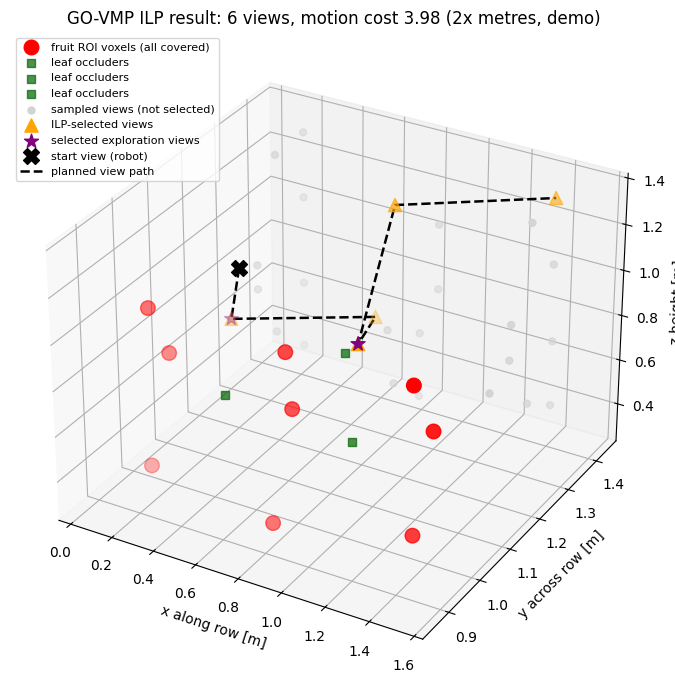

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

fp = np.array(fruit_pos)
ax.scatter(fp[:, 0], fp[:, 1], fp[:, 2], c="red", s=110, marker="o", label="fruit ROI voxels (all covered)")
for (cx, cy, cz), r in leaf_clusters:
    ax.scatter([cx], [cy], [cz], c="darkgreen", s=35, marker="s", alpha=0.7, label="leaf occluders")

vp = np.array(views)
unsel = [i for i in range(n_views) if i not in selected]
ax.scatter(vp[unsel, 0], vp[unsel, 1], vp[unsel, 2], c="lightgray", s=25, label="sampled views (not selected)")
sel_arr = np.array([i for i in selected if i != 0])
ax.scatter(vp[sel_arr, 0], vp[sel_arr, 1], vp[sel_arr, 2], c="orange", s=90, marker="^", label="ILP-selected views")
exsel = [i for i in expl_ids if v[i].X > 0.5]
if exsel:
    ax.scatter(vp[exsel, 0], vp[exsel, 1], vp[exsel, 2], c="purple", s=110, marker="*", label="selected exploration views")
ax.scatter([vp[0, 0]], [vp[0, 1]], [vp[0, 2]], c="black", s=130, marker="X", label="start view (robot)")

pp = np.array([views[i] for i in path])
ax.plot(pp[:, 0], pp[:, 1], pp[:, 2], "k--", lw=1.8, label="planned view path")

ax.set_xlabel("x along row [m]"); ax.set_ylabel("y across row [m]"); ax.set_zlabel("z height [m]")
ax.set_title(f"GO-VMP ILP result: {len(selected)} views, motion cost {model.ObjVal:.2f} (2x metres, demo)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

### Results table and CSV export

A small table of the planned walk (path order, view id, kind, position, motion cost of each hop) and
the solver summary, exported as CSV inside the Colab VM (`/content/govmp_demo_results.csv`). In the
paper these per-segment quantities are aggregated over 16 segments × stochastic runs into Tables I–IV;
a single deterministic example here is only a structural check, **not** a dataset-level result.

**結果表と CSV 出力:** 計画された経路(順序・視点 ID・種別・位置・ホップのコスト)とソルバ概要を出力し、
Colab VM 内に CSV として保存します。単一例は構造確認であり、論文の表 I–IV の再現ではありません。

In [ ]:
import pandas as pd

rows = []
for hop, i in enumerate(path):
    prev = path[hop - 1] if hop > 0 else None
    rows.append({
        "hop": hop,
        "view_id": i,
        "kind": view_kind[i],
        "x_m": round(float(views[i][0]), 3),
        "y_m": round(float(views[i][1]), 3),
        "z_m": round(float(views[i][2]), 3),
        "hop_cost_2x_m": None if prev is None else round(float(cost[prev, i]), 3),
    })
df = pd.DataFrame(rows)
summary = pd.DataFrame([
    {"metric": "selected views (excl. virtual end)", "value": len(selected)},
    {"metric": "path hops", "value": len(path) - 1},
    {"metric": "total motion cost (2x m)", "value": round(float(model.ObjVal), 3)},
    {"metric": "fruit targets covered", "value": f"{len(fruit_pos)}/{len(fruit_pos)}"},
    {"metric": "exploration views selected", "value": sum(1 for i in expl_ids if v[i].X > 0.5)},
    {"metric": "solver runtime [s]", "value": round(float(model.Runtime), 2)},
])
display(summary)
display(df)
df.to_csv("/content/govmp_demo_results.csv", index=False)
print("saved /content/govmp_demo_results.csv")

,metric,value
0,selected views (excl. virtual end),6
1,path hops,5
2,total motion cost (2x m),3.975
3,fruit targets covered,9/9
4,exploration views selected,2
5,solver runtime [s],1.32


,hop,view_id,kind,x_m,y_m,z_m,hop_cost_2x_m
0,0,0,start,0.05,1.300,0.800,NaN
1,1,25,exploration,0.30,1.120,0.850,0.624
2,2,11,fruit,0.80,1.243,0.845,1.030
3,3,26,exploration,0.90,1.120,0.900,0.336
4,4,15,fruit,0.83,1.283,1.295,0.865
5,5,24,fruit,1.37,1.431,1.295,1.119


saved /content/govmp_demo_results.csv


## Interpretation, differences from the paper, and references / 解釈と論文との差分

**What was executed (this run):** the full pipeline above ran top-to-bottom on a fresh Google Colab
**CPU** runtime: the deterministic mini scene was built, views were sampled and visibility-checked, the
5-NN sparse graph and 2×-distance cost matrix were formed, and the GO-VMP ILP (with lazy subtour
elimination) was solved to optimality by Gurobi. The outputs above are from that run; the results
table and figure reflect the actual solved instance. The optimizer returns a minimum-motion-cost walk
from the robot's start pose that covers every fruit ROI at least once and includes the required
exploration views — the paper's global-optimization behavior on a miniature scale.

**Differences from the paper (all labeled at their cells):** ROS/Gazebo/MoveIt/OctoMap are replaced by
a deterministic synthetic segment and geometric proxies; motion cost is pose-space Euclidean (×2)
instead of MoveIt joint-space distance; the shipped `motionCostMatrix` assignment-bug
(`viewpose_graph.cpp:793-818`) is not replicated — non-graph edges are forbidden as the paper
describes; `TimeLimit=60 s` and the exploration target count are demo values (author defaults are ROS
parameters not present in the repository); single-shot planning instead of the 12 s re-planning cycle;
one segment instead of 16; gurobipy pip size-limited license instead of a full Gurobi 11.0.1 license.
**この差分はすべて各セルに明記した適応です。**

**Not verified here:** the paper's Scenario 1/2 statistics, ablations, baseline comparisons, and the
real-robot deployment. The Gurobi limited license and the proxies above bound instance sizes and
fidelity; running the authors' full ROS stack remains the faithful route for dataset-level claims.

**References:**
1. Jose et al., *GO-VMP: Global Optimization for View Motion Planning in Fruit Mapping*, arXiv:2503.03912v2, 2025. https://arxiv.org/abs/2503.03912
2. Author implementation: https://github.com/AllenIsaacJose/GO-VMP (commit `ba17f5f5f2c674a7a84b047cb25dea00376fed64`, AGPL-3.0). Ported file: `src/view_motion_planner/src/views_voxels_motion.cpp` (verified blob SHA-1 `fd55ba1c…`), plus `viewpose_graph.cpp` for graph/cost/visibility definitions.
3. Related context cited by the paper: Zaenker et al., *Graph-based View Motion Planning for Fruit Detection*, IROS 2023 (arXiv:2303.03048); supplement video https://youtu.be/mSWlDTn5ykg.